# 09 — Aggregate comparison report

**Dataset:** `aim_2023`

Reads saved artifacts only. Different tasks stay separate. No winner forced.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.comparison import METHOD_LABELS, RECORDING_METHODS, WINDOW_METHODS, build_recording_score_matrix, build_window_score_matrix, rank_method_scores
from lap_estimation.integration import build_recurrence_fusion, build_window_consensus
from lap_estimation.plotting_fusion import render_fusion_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "aim_2023"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,228.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,217.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,210.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
3,5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3...,25.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
4,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,89.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
5,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,33.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
6,6732a35a8f6343dcf041f1a3ad40d6760331513a2556c4...,21.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
7,7208a43e77536a72e401c00f01a793130fb6688d28fb80...,9.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
8,73093667f33a7f710fc20059989a002071359119e1e9c0...,10.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
9,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,107.95,dynamic_candidate,False,inferred_uniform_from_metadata,train


In [2]:
METHODS = ["01_signal_processing", "02_dtw", "03_correlation", "04_learned_embeddings", "05_autoencoders", "06_contrastive_learning", "07_sequence_models", "08_unsupervised_learning"]
status_rows = []
for method in METHODS:
    path = ARTIFACT_ROOT / method / "manifest.json"
    if path.exists():
        run = json.loads(path.read_text(encoding="utf-8"))
        status_rows.append(
            {
                "method": method,
                "status": run.get("status"),
                "task": run.get("task"),
                "runtime_s": run.get("runtime_s"),
                "clock_provenance": run.get("data_provenance", {}).get("clock_provenance"),
                "sample_rate_hz": run.get("data_provenance", {}).get("native_sample_rate_hz"),
                "label_provenance": run.get("label_provenance"),
            }
        )
    else:
        status_rows.append({"method": method, "status": "not_run"})
run_status = pd.DataFrame(status_rows)
run_status

,method,status,task,runtime_s,clock_provenance,sample_rate_hz,label_provenance
0,01_signal_processing,complete,unverified_recurrence_period_detection,3.415,inferred_uniform_from_metadata,20.0,signal_processing_teacher_unverified
1,02_dtw,complete,time_warped_period_pair_retrieval,6.412,inferred_uniform_from_metadata,20.0,signal_period_teacher_unverified
2,03_correlation,complete,channel_recurrence_and_sensor_lag,7.343,inferred_uniform_from_metadata,20.0,unverified_channel_recurrence
3,04_learned_embeddings,complete,masked_signal_representation_learning,5.602,inferred_uniform_from_metadata,20.0,self_supervised_unverified
4,05_autoencoders,complete,window_reconstruction_and_latent_neighbors,5.572,inferred_uniform_from_metadata,20.0,reconstruction_score_unverified
5,06_contrastive_learning,complete,self_supervised_contrastive_retrieval,9.557,inferred_uniform_from_metadata,20.0,same_window_augmentations_unverified
6,07_sequence_models,complete,next_sample_prediction,26.096,inferred_uniform_from_metadata,20.0,prediction_error_unverified
7,08_unsupervised_learning,complete,driving_regime_clustering,3.719,inferred_uniform_from_metadata,20.0,cluster_regime_not_lap


In [3]:
metrics = load_experiment_metrics(ARTIFACT_ROOT)
display(metrics.sort_values(["task", "metric", "method"]))
comparison_keys = ["task", "split", "metric", "reference_source"]
comparison_table = metrics.pivot_table(index=comparison_keys, columns="method", values="value", aggfunc="first")
display(comparison_table)
metrics.to_csv(ARTIFACT_ROOT / "comparison_metrics.csv", index=False)

,method,task,split,metric,value,sample_count,reference_source
36,06_contrastive_learning,augmentation_retrieval,train,mean_view_cosine_similarity,0.986389,662,same_window_augmentations
37,06_contrastive_learning,augmentation_retrieval,validation,mean_view_cosine_similarity,0.981839,61,same_window_augmentations
38,06_contrastive_learning,augmentation_retrieval,test,mean_view_cosine_similarity,0.989772,213,same_window_augmentations
39,06_contrastive_learning,augmentation_retrieval,all,mean_view_cosine_similarity,0.986863,936,same_window_augmentations
12,03_correlation,channel_lag_consensus,train,mean_lag_mad_s,2.371429,7,none
13,03_correlation,channel_lag_consensus,validation,mean_lag_mad_s,0.250000,1,none
14,03_correlation,channel_lag_consensus,test,mean_lag_mad_s,5.000000,2,none
15,03_correlation,channel_lag_consensus,all,mean_lag_mad_s,2.685000,10,none
3,01_signal_processing,data_quality,all,duplicate_alias_count,0.000000,18,sha256
55,08_unsupervised_learning,driving_regime_clustering,train,mean_centroid_distance,1.938081,662,none


method                                                                                                 01_signal_processing  \
task                      split      metric                            reference_source                                       
augmentation_retrieval    all        mean_view_cosine_similarity       same_window_augmentations                        NaN   
                          test       mean_view_cosine_similarity       same_window_augmentations                        NaN   
                          train      mean_view_cosine_similarity       same_window_augmentations                        NaN   
                          validation mean_view_cosine_similarity       same_window_augmentations                        NaN   
channel_lag_consensus     all        mean_lag_mad_s                    none                                             NaN   
                          test       mean_lag_mad_s                    none                                             NaN   
                          train      mean_lag_mad_s                    none                                             NaN   
                          validation mean_lag_mad_s                    none                                             NaN   
data_quality              all        duplicate_alias_count             sha256                                      0.000000   
driving_regime_clustering all        mean_centroid_distance            none                                             NaN   
                          test       mean_centroid_distance            none                                             NaN   
                          train      mean_centroid_distance            none                                             NaN   
                                     seed_adjusted_rand_index          internal_only                                    NaN   
                                     selected_cluster_count            internal_selection                               NaN   
                                     silhouette                        internal_only                                    NaN   
                          validation mean_centroid_distance            none                                             NaN   
embedding_retrieval       all        mean_neighbor_cosine_similarity   none                                             NaN   
                          test       mean_neighbor_cosine_similarity   none                                             NaN   
                          train      mean_neighbor_cosine_similarity   none                                             NaN   
                          validation mean_neighbor_cosine_similarity   none                                             NaN   
masked_signal_prediction  all        mean_reconstruction_mse           none                                             NaN   
                          test       mean_reconstruction_mse           none                                             NaN   
                          train      mean_reconstruction_mse           none                                             NaN   
                          validation mean_reconstruction_mse           none                                             NaN   
next_sample_prediction    all        gru_mse                           none                                             NaN   
                                     persistence_mse                   persistence_baseline                             NaN   
                          test       gru_mse                           none                                             NaN   
                                     persistence_mse                   persistence_baseline                             NaN   
                          train      gru_mse                           none                                             NaN   
                                     persistence_mse           

In [4]:
def metric_value(method, metric, split="test"):
    selected = metrics.loc[(metrics["method"] == method) & (metrics["metric"] == metric) & (metrics["split"] == split), "value"]
    return float(selected.iloc[0]) if len(selected) else np.nan


findings = pd.DataFrame(
    [
        {"method": "Signal processing", "result": metric_value("01_signal_processing", "non_control_review_candidate_rate", "all"), "reading": "Review-candidate rate only; control detections remain visible."},
        {"method": "DTW", "result": metric_value("02_dtw", "matched_better_than_control_rate"), "reading": "Above 0.5 supports teacher-period pairs only."},
        {"method": "Correlation", "result": metric_value("03_correlation", "mean_lag_mad_s"), "reading": "Lower channel lag spread means consistency, not accuracy."},
        {"method": "Learned embeddings", "result": metric_value("04_learned_embeddings", "mean_neighbor_cosine_similarity"), "reading": "Near-unity values may mean overlap or collapse."},
        {"method": "Autoencoder", "result": metric_value("05_autoencoders", "autoencoder_mse") - metric_value("05_autoencoders", "pca_mse"), "reading": "Negative delta beats PCA."},
        {"method": "Contrastive learning", "result": metric_value("06_contrastive_learning", "mean_view_cosine_similarity"), "reading": "Measures augmentation invariance only."},
        {"method": "Sequence model", "result": metric_value("07_sequence_models", "gru_mse") - metric_value("07_sequence_models", "persistence_mse"), "reading": "Negative delta beats persistence."},
        {"method": "Unsupervised learning", "result": metric_value("08_unsupervised_learning", "seed_adjusted_rand_index", "train"), "reading": "Stable clusters remain operating regimes."},
    ]
)
findings.to_csv(ARTIFACT_ROOT / "report_findings.csv", index=False)
findings

,method,result,reading
0,Signal processing,0.125000,Review-candidate rate only; control detections...
1,DTW,0.700000,Above 0.5 supports teacher-period pairs only.
2,Correlation,5.000000,"Lower channel lag spread means consistency, no..."
3,Learned embeddings,0.999793,Near-unity values may mean overlap or collapse.
4,Autoencoder,0.313795,Negative delta beats PCA.
5,Contrastive learning,0.989772,Measures augmentation invariance only.
6,Sequence model,13.225456,Negative delta beats persistence.
7,Unsupervised learning,1.000000,Stable clusters remain operating regimes.


## Method-score pairplots

Recording view aggregates each method to median score per recording. Percentile ranks make unlike scales comparable. Reconstruction and sequence errors are reversed so higher rank means lower error. Complete-case count is small.

Window view uses exact shared windows from embeddings, autoencoder, contrastive, sequence, and unsupervised methods. Overlapping windows are dependent observations. Correlations describe score behavior, not agreement on true laps.

,count
all_recordings,18
complete_recordings,10


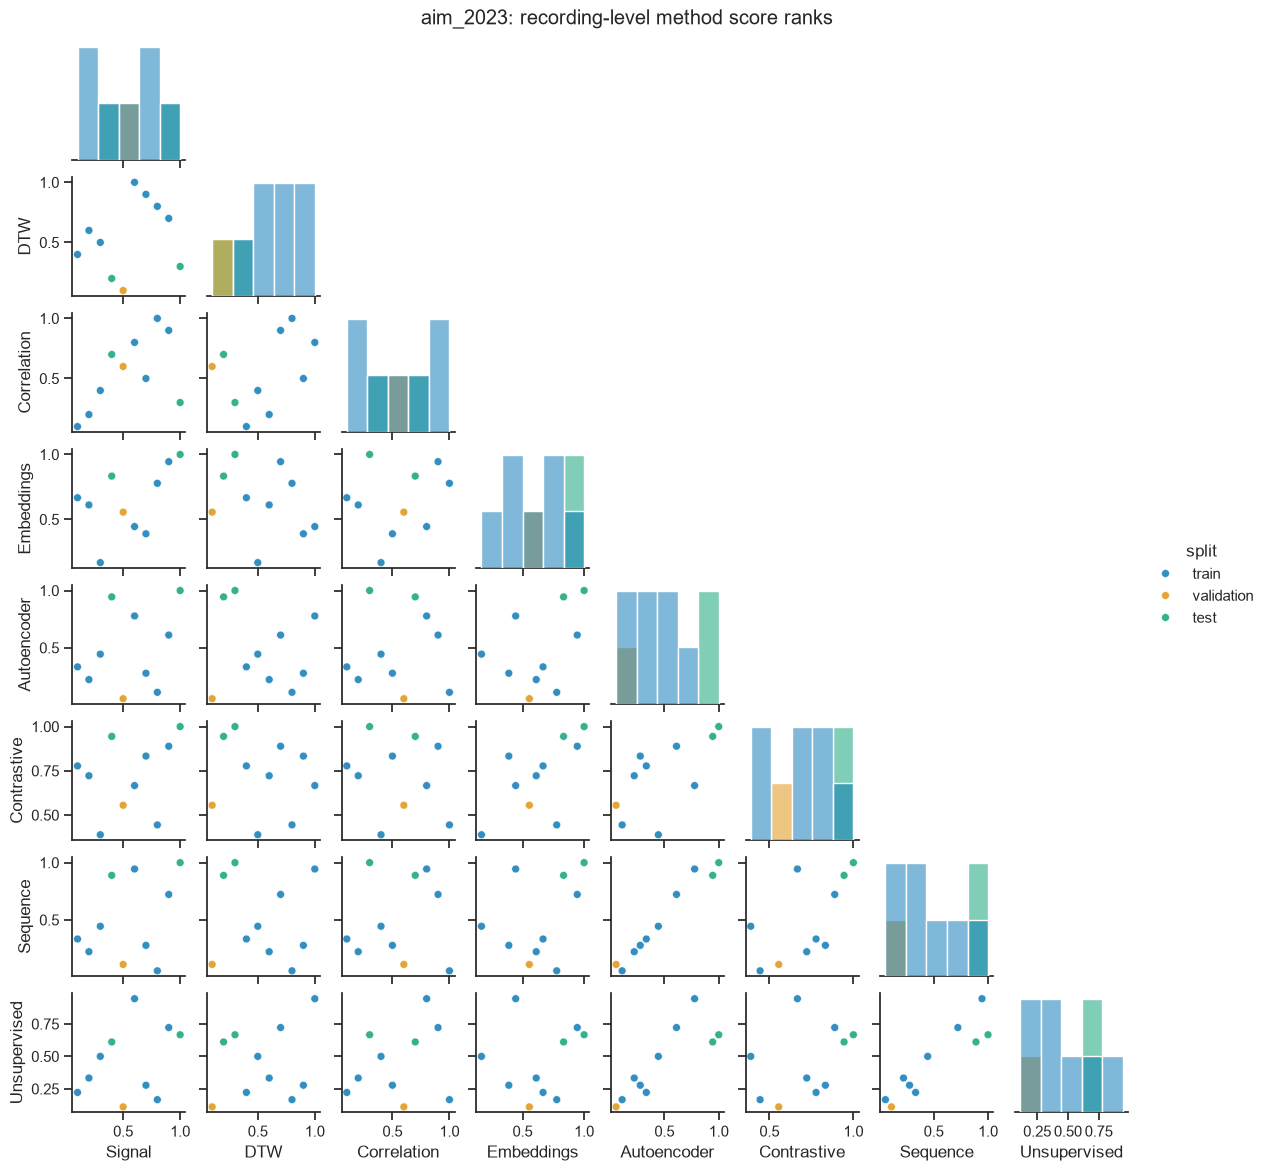

In [5]:
sns.set_theme(style="ticks", palette="colorblind")
recording_scores = build_recording_score_matrix(ARTIFACT_ROOT)
recording_ranks = rank_method_scores(recording_scores, ["recording_id"])
recording_plot = recording_ranks.merge(manifest[["recording_id", "split", "motion_status"]], on="recording_id", how="left")
recording_columns = [METHOD_LABELS[method] for method in RECORDING_METHODS]
recording_complete = recording_plot.dropna(subset=recording_columns)
display(pd.Series({"all_recordings": len(recording_plot), "complete_recordings": len(recording_complete)}, name="count").to_frame())
grid = sns.pairplot(
    recording_complete,
    vars=recording_columns,
    hue="split",
    corner=True,
    diag_kind="hist",
    height=1.45,
    plot_kws={"s": 32, "alpha": 0.8},
)
grid.figure.suptitle(f"{DATASET_KEY}: recording-level method score ranks", y=1.01)
grid.savefig(ARTIFACT_ROOT / "recording_method_pairplot.png", dpi=180, bbox_inches="tight")
recording_plot.to_csv(ARTIFACT_ROOT / "recording_method_scores.csv", index=False)

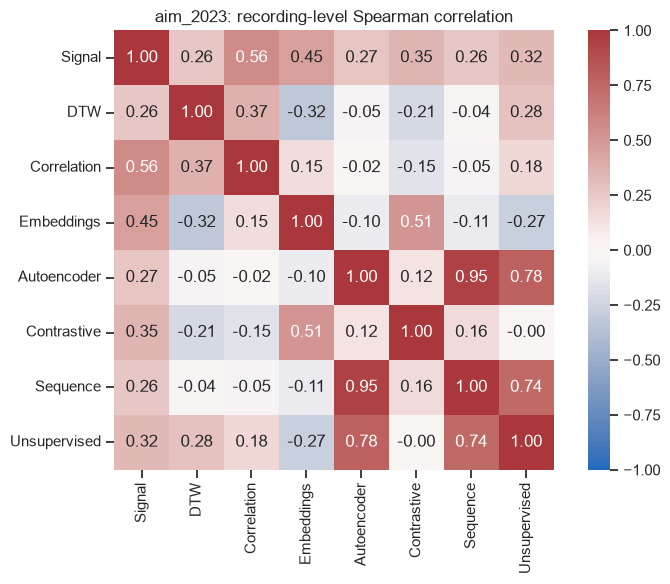

In [6]:
recording_correlation = recording_ranks[recording_columns].corr(method="spearman", min_periods=5)
recording_correlation.to_csv(ARTIFACT_ROOT / "recording_method_spearman.csv")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(recording_correlation, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title(f"{DATASET_KEY}: recording-level Spearman correlation")
fig.tight_layout()
fig.savefig(ARTIFACT_ROOT / "recording_method_spearman.png", dpi=180, bbox_inches="tight")

,Embeddings,Autoencoder,Contrastive,Sequence,Unsupervised
Embeddings,1.000000,0.010939,0.460625,0.001457,-0.118054
Autoencoder,0.010939,1.000000,0.163832,0.984014,0.813024
Contrastive,0.460625,0.163832,1.000000,0.140782,0.028069
Sequence,0.001457,0.984014,0.140782,1.000000,0.814169
Unsupervised,-0.118054,0.813024,0.028069,0.814169,1.000000


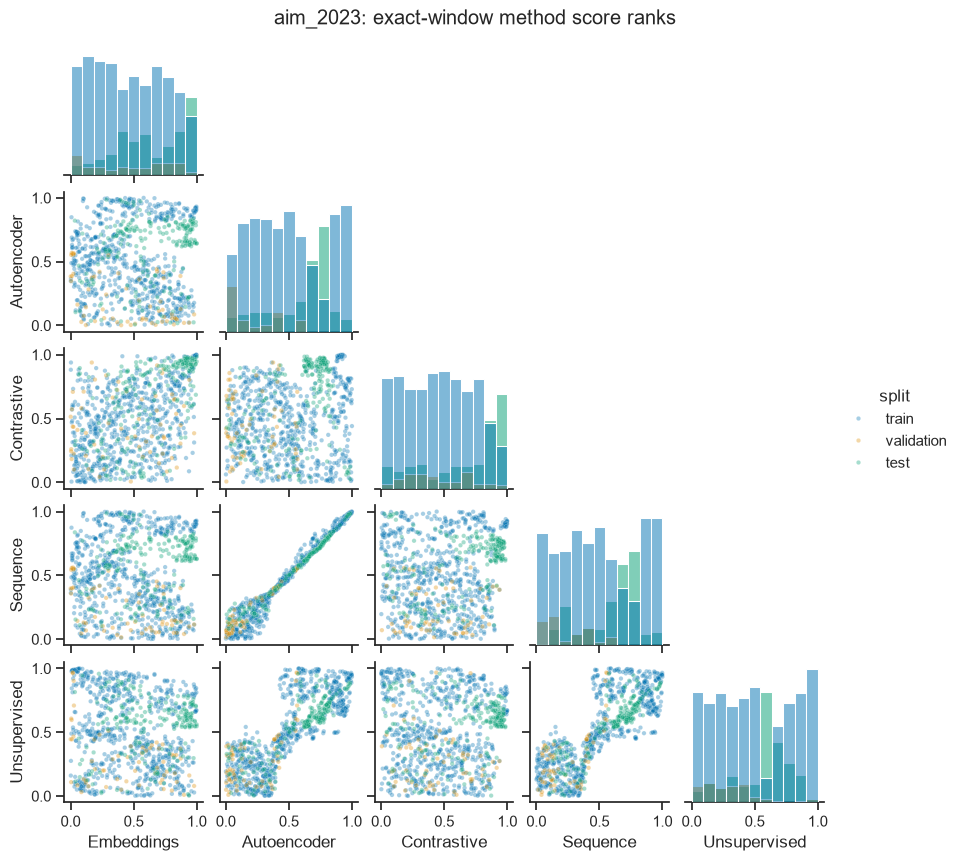

In [7]:
window_scores = build_window_score_matrix(ARTIFACT_ROOT)
window_keys = ["recording_id", "start_s", "end_s"]
window_ranks = rank_method_scores(window_scores, window_keys)
window_plot = window_ranks.merge(manifest[["recording_id", "split"]], on="recording_id", how="left")
window_columns = [METHOD_LABELS[method] for method in WINDOW_METHODS]
grid = sns.pairplot(
    window_plot,
    vars=window_columns,
    hue="split",
    corner=True,
    diag_kind="hist",
    height=1.7,
    plot_kws={"s": 10, "alpha": 0.35},
)
grid.figure.suptitle(f"{DATASET_KEY}: exact-window method score ranks", y=1.01)
grid.savefig(ARTIFACT_ROOT / "window_method_pairplot.png", dpi=180, bbox_inches="tight")
window_plot.to_csv(ARTIFACT_ROOT / "window_method_scores.csv", index=False)
window_correlation = window_ranks[window_columns].corr(method="spearman")
window_correlation.to_csv(ARTIFACT_ROOT / "window_method_spearman.csv")
window_correlation

## Family-aware integration

Recurrence fusion combines signal/correlation period evidence with DTW shape support. DTW depends on signal-derived teacher periods, so those two are not independent votes. Window consensus normalizes learned-method scores against training distributions only. Autoencoder and sequence errors contribute typicality context, not lap votes.

,recording_id,signal_score,signal_period_s,dtw_margin,dtw_pair_count,correlation_score,correlation_period_s,period_agreement,signal_support,dtw_support,correlation_support,period_support,signal_family_support,shape_family_support,fused_support,family_dispersion,method_count,evidence_status,dependency_note
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,0.250696,45.50,1.714187,10,0.237398,45.45,0.998901,0.9,0.7,0.7,1.0,0.9,0.7,0.80,0.10,3,review,dtw_uses_signal_period_teacher
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,0.204464,20.10,21.964125,10,0.246157,45.90,0.437908,0.6,1.0,0.9,0.2,0.6,1.0,0.80,0.20,3,weak,dtw_uses_signal_period_teacher
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,0.228681,21.00,20.480237,10,0.236365,21.10,0.995261,0.7,0.9,0.6,0.7,0.7,0.9,0.80,0.10,3,review,dtw_uses_signal_period_teacher
3,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,0.232961,45.15,6.738922,10,0.340034,45.00,0.996678,0.8,0.8,1.0,0.8,0.8,0.8,0.80,0.00,3,review,dtw_uses_signal_period_teacher
4,dc8bf44eb4cc0becf1c5ebe252a515c98193744c203149...,0.253938,27.45,0.035632,10,0.176058,27.50,0.998182,1.0,0.3,0.3,0.9,0.9,0.3,0.60,0.30,3,weak,dtw_uses_signal_period_teacher
5,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,0.176924,39.95,0.487705,10,0.225389,44.15,0.904870,0.3,0.5,0.5,0.4,0.4,0.5,0.45,0.05,3,weak,dtw_uses_signal_period_teacher
6,9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e72...,0.118885,59.15,0.786747,10,0.109353,15.15,0.256128,0.2,0.6,0.1,0.1,0.1,0.6,0.35,0.25,3,weak,dtw_uses_signal_period_teacher
7,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,0.002243,15.25,0.198161,2,0.117204,15.80,0.965190,0.1,0.4,0.2,0.6,0.2,0.4,0.30,0.10,3,weak,dtw_uses_signal_period_teacher
8,bace0e92b25324e8afbd0e5f6698b01a921780a2385e02...,0.189051,15.05,-0.017128,10,0.221776,23.80,0.632353,0.4,0.2,0.4,0.3,0.4,0.2,0.30,0.10,3,weak,dtw_uses_signal_period_teacher
9,b185f43818b8ff3aba325752922bbbf37fd094f1e28288...,0.196036,46.00,-1.432502,10,0.240730,50.15,0.917248,0.5,0.1,0.8,0.5,0.5,0.1,0.30,0.20,3,weak,dtw_uses_signal_period_teacher


,recording_id,start_s,end_s,Embeddings,Autoencoder,Contrastive,Sequence,Unsupervised,split,Embeddings_support,Autoencoder_support,Contrastive_support,Sequence_support,Unsupervised_support,consensus_support,support_iqr,method_count
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,0.0,10.0,0.999985,1.263434,0.995855,1.924615,-1.752613,train,0.645015,0.451662,0.930514,0.425982,0.432024,0.451662,0.212991,5
1,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,2.0,12.0,0.999750,0.474689,0.990964,0.383169,-0.587018,train,0.249245,0.569486,0.814199,0.580060,0.879154,0.580060,0.244713,5
2,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,4.0,14.0,0.999999,0.056868,0.985927,0.053276,-0.631642,train,0.981873,0.868580,0.682779,0.845921,0.841390,0.845921,0.027190,5
3,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,6.0,16.0,0.999994,0.055263,0.994272,0.052744,-0.661098,train,0.848943,0.876133,0.906344,0.851964,0.788520,0.851964,0.027190,5
4,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,8.0,18.0,0.999994,0.060315,0.994491,0.057648,-0.665145,train,0.826284,0.845921,0.916918,0.830816,0.774924,0.830816,0.019637,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,dc8bf44eb4cc0becf1c5ebe252a515c98193744c203149...,158.0,168.0,0.999891,0.427027,0.951580,0.295741,-0.945333,test,0.339879,0.584592,0.216012,0.598187,0.570997,0.570997,0.244713,5
932,dc8bf44eb4cc0becf1c5ebe252a515c98193744c203149...,160.0,170.0,0.999994,2.247686,0.994862,1.773196,-2.301107,test,0.833837,0.416918,0.921450,0.429003,0.350453,0.429003,0.416918,5
933,dc8bf44eb4cc0becf1c5ebe252a515c98193744c203149...,162.0,172.0,0.999989,2.464107,0.989217,2.838751,-3.393374,test,0.716012,0.409366,0.771903,0.416918,0.188822,0.416918,0.306647,5
934,dc8bf44eb4cc0becf1c5ebe252a515c98193744c203149...,164.0,174.0,0.999990,2.398451,0.993499,3.337969,-4.142009,test,0.722054,0.412387,0.888218,0.410876,0.122356,0.412387,0.311178,5


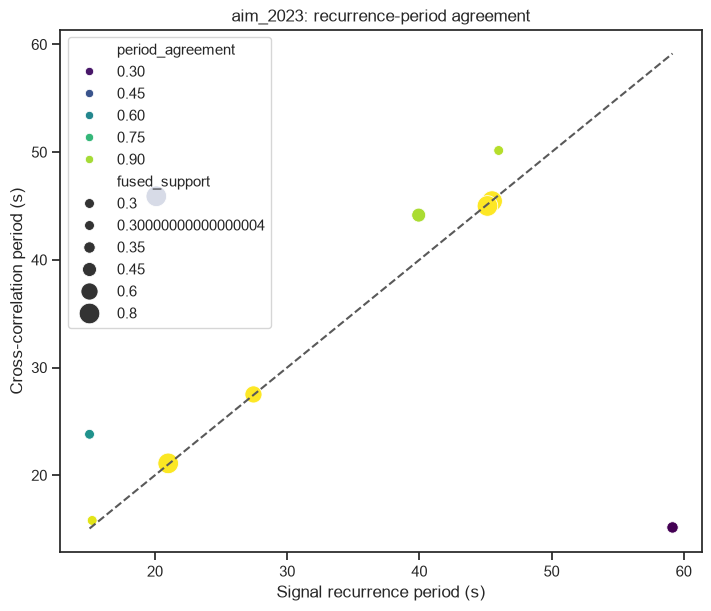

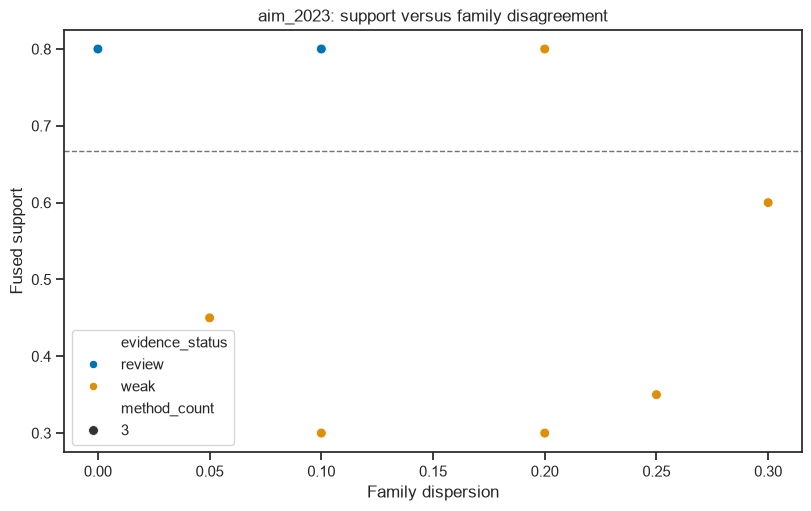

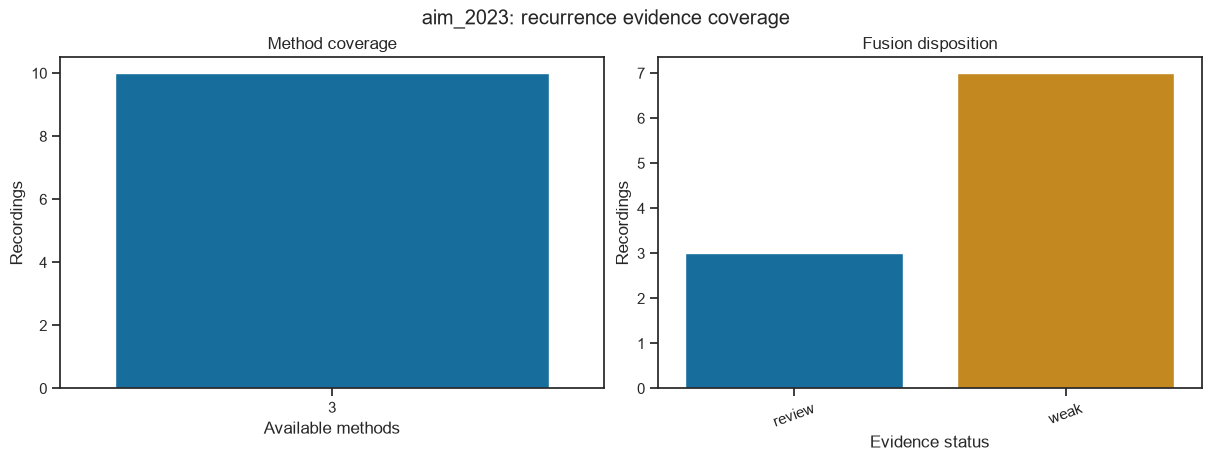

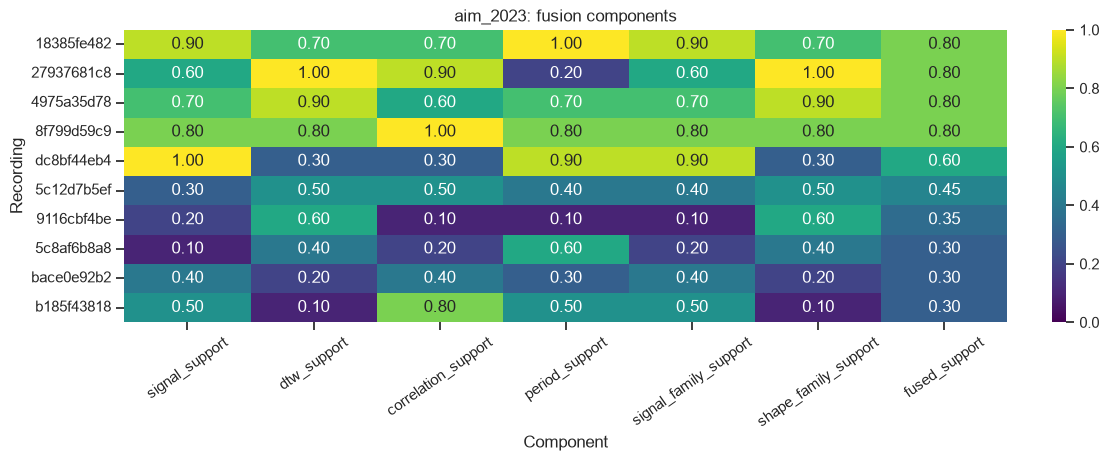

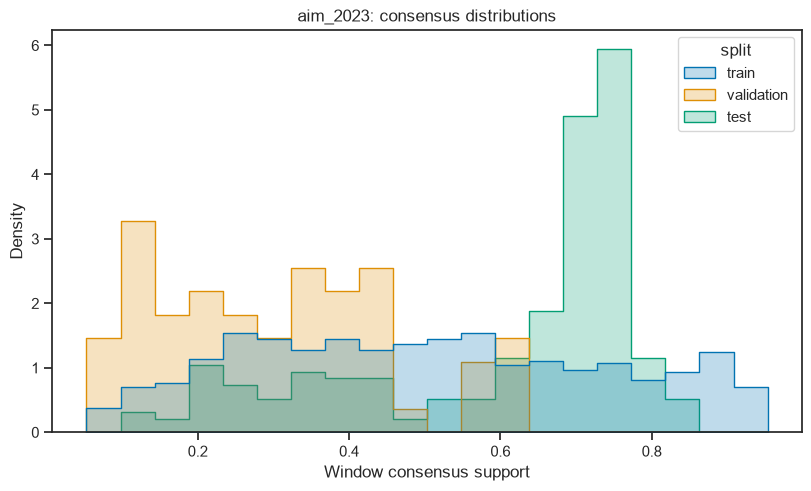

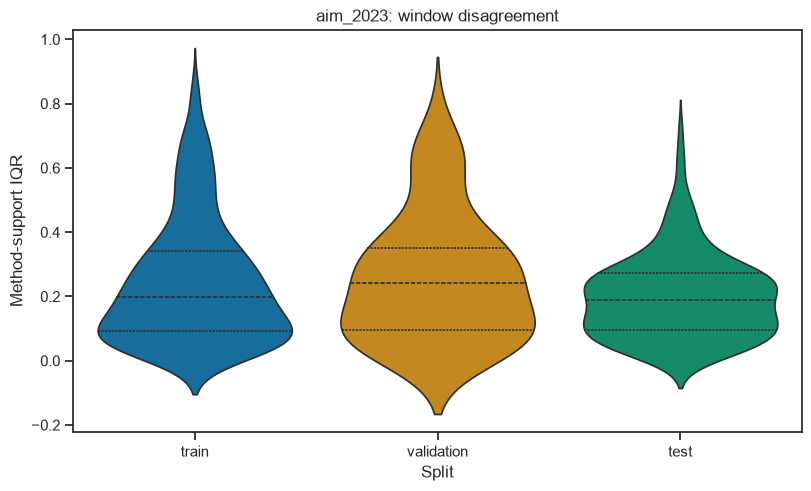

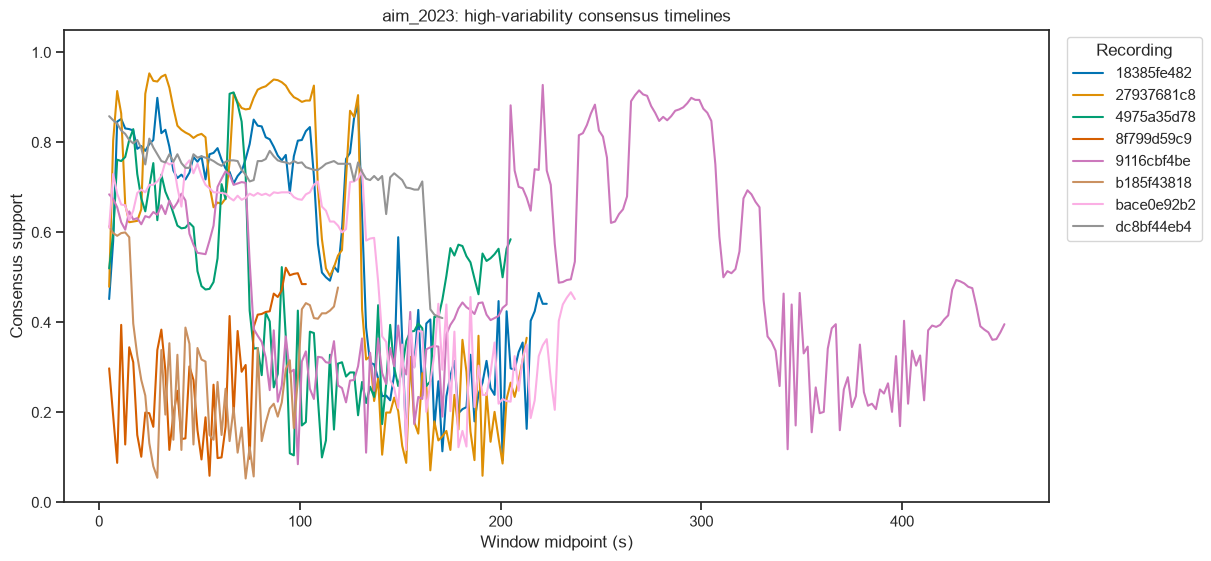

In [8]:
recurrence_fusion = build_recurrence_fusion(ARTIFACT_ROOT)
window_consensus = build_window_consensus(ARTIFACT_ROOT)
recurrence_fusion.to_csv(ARTIFACT_ROOT / "recurrence_fusion.csv", index=False)
window_consensus.to_csv(ARTIFACT_ROOT / "window_consensus.csv", index=False)
display(recurrence_fusion)
display(window_consensus.sort_values(["recording_id", "start_s"]))

fusion_figures = render_fusion_diagnostics(recurrence_fusion, window_consensus, {"dataset_key": DATASET_KEY}, ARTIFACT_ROOT)
for figure in fusion_figures.values():
    display(figure)
    plt.close(figure)

## Report boundary

No independent lap boundaries or GPS exist. Report compares engineering evidence, baselines, stability, and failure behavior. It cannot name an accurate lap detector.